### Have all the packages needed so they can be loaded at once for the whole notebook

In [3]:
#Load the different packages needed
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Transform the Excel file into individual .csv files

In [ ]:
path = r"C:\Users\sebas\OneDrive\Escritorio\Critical Mass Case Study"
files = os.listdir(path)

for eachfile in files:
    if eachfile.endswith(".xlsx"):
        # Get the full path to open the file
        fullpath = os.path.join(path, eachfile)
        
        # Clean the filename for the output
        cleanfilename = eachfile.replace(".xlsx", "")
        
        xfile = pd.ExcelFile(fullpath)
        sheets = xfile.sheet_names
        
        for eachsheet in sheets:
            sheetdata = xfile.parse(eachsheet)
            
            # Create the new CSV name using MKS Case Study to make it shorter
            csvname = f"MKS Case Study_{eachsheet}.csv"
            
            # Join with path so the CSVs save in the same folder
            output_path = os.path.join(path, csvname)
            
            sheetdata.to_csv(output_path, index=False)
            print(f"Successfully created: {csvname}")

### Assign names to each .csv file for easier use. Then define functions so the data set can be explored and understood

In [7]:
metrics2023=r"C:\Users\sebas\OneDrive\Escritorio\Critical Mass Case Study\Files\MKS Case Study_Website Metrics - 2023.csv"
metrics2024=r"C:\Users\sebas\OneDrive\Escritorio\Critical Mass Case Study\Files\MKS Case Study_Website Metrics - 2024.csv"
enginetype=r"C:\Users\sebas\OneDrive\Escritorio\Critical Mass Case Study\Files\MKS Case Study_Model - Engine Type.csv"


In [8]:
# Load the data using functions
df23 = pd.read_csv(metrics2023)
df24 = pd.read_csv(metrics2024)
dfengine = pd.read_csv(enginetype)

In [9]:
#Checking the size of each tab in the excel document (rows, columns)
size23 = df23.shape
size24 = df24.shape
sizeengine = dfengine.shape
print(size23)
print(size24)
print(sizeengine)

(2181, 19)
(2268, 20)
(6, 2)


In [ ]:
df23.head() #In order to check the dataset

,date,model,start_configuration,complete_configuration,finance_calculator_visits,test_drives_submitted,finance_calc_leads_submitted,request_a_quote_form_submitted,showrooms_visits,visits,natural_search_visits,paid_search_visits,paid_social_visits,email_visits,direct_visits,bounces,return_visitors,unique_visitors,quality_arrivals
0,"Jan 17, 2023",Model_A,1831,688,179,3,0,6,2570,3516,1960,1155,0,17,302,128,1087,3232,1845
1,"Jan 1, 2024",Model_F,264,77,30,1,0,0,774,966,541,267,0,1,150,60,281,868,265
2,"Jan 9, 2023",Model_D,864,353,166,4,0,10,1324,1913,1538,38,0,39,233,59,730,1712,869
3,"Jan 20, 2023",Model_E,448,167,75,7,0,0,955,1132,757,230,0,3,131,147,418,1058,451
4,"Jan 21, 2023",Model_A,1866,705,169,2,0,2,2783,3735,2013,1295,0,19,339,139,1047,3446,1874


In [ ]:
df24.head() #In order to check the dataset

,date,Useable Date,model,start_configuration,complete_configuration,finance_calculator_visits,test_drives_submitted,finance_calc_leads_submitted,request_a_quote_form_submitted,car_model_visits,visits,natural_search_visits,paid_search_visits,paid_social_visits,email_visits,direct_visits,bounces,return_visitors,unique_visitors,Engine Type
0,"Jan 2, 2024",2024-01-02,Model_E,341,93,30,17,0,2,1016,1489,733,559,26,12,245,20,488,1397,BEV
1,"Jan 6, 2024",2024-01-06,Model_E,272,85,97,8,0,2,810,1290,712,340,75,4,197,14,400,1215,BEV
2,"Jan 10, 2024",2024-01-10,Model_E,325,77,129,9,0,2,879,1364,788,356,48,9,210,16,529,1292,BEV
3,"Jan 14, 2024",2024-01-14,Model_E,221,55,132,2,0,0,710,1198,616,373,41,7,203,15,415,1142,BEV
4,"Jan 18, 2024",2024-01-18,Model_E,288,84,106,10,0,0,871,1300,760,286,46,13,202,22,480,1219,BEV


In [59]:
dfengine.head(7) #In order to check the dataset

,model,engine_type
0,Model_A,ICE
1,Model_B,ICE
2,Model_C,ICE
3,Model_D,ICE
4,Model_E,BEV
5,Model_F,BEV


### Cleaning the headers vital for integrity of the data

In [10]:
# Apply the clean_columns function to ensure all datasets follow the same naming convention
def clean_columns(df):
    df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_') #strip removes spaces at the beginning or end, lower for lowercase and 
    return df                                                              #replace is for spaces '_' into _

df23 = clean_columns(df23)
df24 = clean_columns(df24)
dfengine = clean_columns(dfengine)

#2023 uses 'showrooms_visits' and 2024 uses 'car_model_visits'. The headers must match in order to compare later the information
df23 = df23.rename(columns={'showrooms_visits': 'car_model_visits'})

print("2023 Columns:", df23.columns.tolist())
print("2024 Columns:", df24.columns.tolist())

2023 Columns: ['date', 'model', 'start_configuration', 'complete_configuration', 'finance_calculator_visits', 'test_drives_submitted', 'finance_calc_leads_submitted', 'request_a_quote_form_submitted', 'car_model_visits', 'visits', 'natural_search_visits', 'paid_search_visits', 'paid_social_visits', 'email_visits', 'direct_visits', 'bounces', 'return_visitors', 'unique_visitors', 'quality_arrivals']
2024 Columns: ['date', 'useable_date', 'model', 'start_configuration', 'complete_configuration', 'finance_calculator_visits', 'test_drives_submitted', 'finance_calc_leads_submitted', 'request_a_quote_form_submitted', 'car_model_visits', 'visits', 'natural_search_visits', 'paid_search_visits', 'paid_social_visits', 'email_visits', 'direct_visits', 'bounces', 'return_visitors', 'unique_visitors', 'engine_type']


In [11]:
# Standardizing Dates for 2023
df23['date'] = pd.to_datetime(df23['date'])

# Standardizing Dates for 2024 
# df24 has 'useable_date' which is already clean. Just rename it to 'date' to match df23.
df24['date'] = pd.to_datetime(df24['useable_date'])
df24 = df24.drop(columns=['useable_date']) # Remove the redundant column

# Adding Engine Type to df23 using a merge
df23 = pd.merge(df23, dfengine, on='model', how='left')

# Verification
print("DF23 Sample with Engine Type:")
print(df23[['date', 'model', 'engine_type']].head())

DF23 Sample with Engine Type:
        date    model engine_type
0 2023-01-17  Model_A         ICE
1 2024-01-01  Model_F         BEV
2 2023-01-09  Model_D         ICE
3 2023-01-20  Model_E         BEV
4 2023-01-21  Model_A         ICE


In [12]:
# Checking for rare values in the data set
# Dropping unique columns to maintain symmetry between tables
df23 = df23.drop(columns=['quality_arrivals'])

In [13]:
# Identify the leaked records before filtering them
leaked_records = df23[df23['date'].dt.year != 2023]

# Filter to ensure each df only has its respective year
df23 = df23[df23['date'].dt.year == 2023].copy()
df24 = df24[df24['date'].dt.year == 2024].copy()

# Create the Master Dataset (both years)
df_all = pd.concat([df23, df24], ignore_index=True)

# Column alignment
print(f"Columns match: {set(df23.columns) == set(df24.columns)}")
print(f"Anomalies found: {len(leaked_records)}")
print(f"Cleaned Dataset Rows: {len(df_all)}")


Columns match: True
Anomalies found: 12
Cleaned Dataset Rows: 4437


In [26]:
df_all.head()

,date,model,start_configuration,complete_configuration,finance_calculator_visits,test_drives_submitted,finance_calc_leads_submitted,request_a_quote_form_submitted,car_model_visits,visits,natural_search_visits,paid_search_visits,paid_social_visits,email_visits,direct_visits,bounces,return_visitors,unique_visitors,engine_type
0,2023-01-17,Model_A,1831,688,179,3,0,6,2570,3516,1960,1155,0,17,302,128,1087,3232,ICE
1,2023-01-09,Model_D,864,353,166,4,0,10,1324,1913,1538,38,0,39,233,59,730,1712,ICE
2,2023-01-20,Model_E,448,167,75,7,0,0,955,1132,757,230,0,3,131,147,418,1058,BEV
3,2023-01-21,Model_A,1866,705,169,2,0,2,2783,3735,2013,1295,0,19,339,139,1047,3446,ICE
4,2023-01-02,Model_D,546,219,102,5,0,0,1048,1370,1136,30,0,17,157,36,463,1268,ICE


In [28]:
# Remove the timestamp
df_all['date'] = df_all['date'].dt.date

print(df_all['date'].head())

0    2023-01-17
1    2023-01-09
2    2023-01-20
3    2023-01-21
4    2023-01-02
Name: date, dtype: object


### Q1: What is the most popular model? Explain your reasoning and what you would do with this finding

In [15]:
# Popularity Analysis
# Popularity based on Volume (Visits) and Intent (CCR).

# Aggregating data by model
popularity_stats = df_all.groupby('model').agg({
    'visits': 'sum',
    'complete_configuration': 'sum'
}).reset_index()

# Calculate CCR (Configuration Completion Rate): Intent to purchase a car
popularity_stats['ccr_%'] = (popularity_stats['complete_configuration'] / popularity_stats['visits']) * 100

# Sorting by Visits to see the "Most Popular" by volume
popularity_stats = popularity_stats.sort_values(by='visits', ascending=False)

print("Model Popularity Ranking:")
print(popularity_stats)

Model Popularity Ranking:
     model   visits  complete_configuration      ccr_%
0  Model_A  2878124                  445945  15.494294
2  Model_C  1873383                  289896  15.474465
3  Model_D  1629273                  187387  11.501265
1  Model_B  1265496                  209970  16.591913
5  Model_F  1040062                   68337   6.570474
4  Model_E   757030                   71444   9.437407


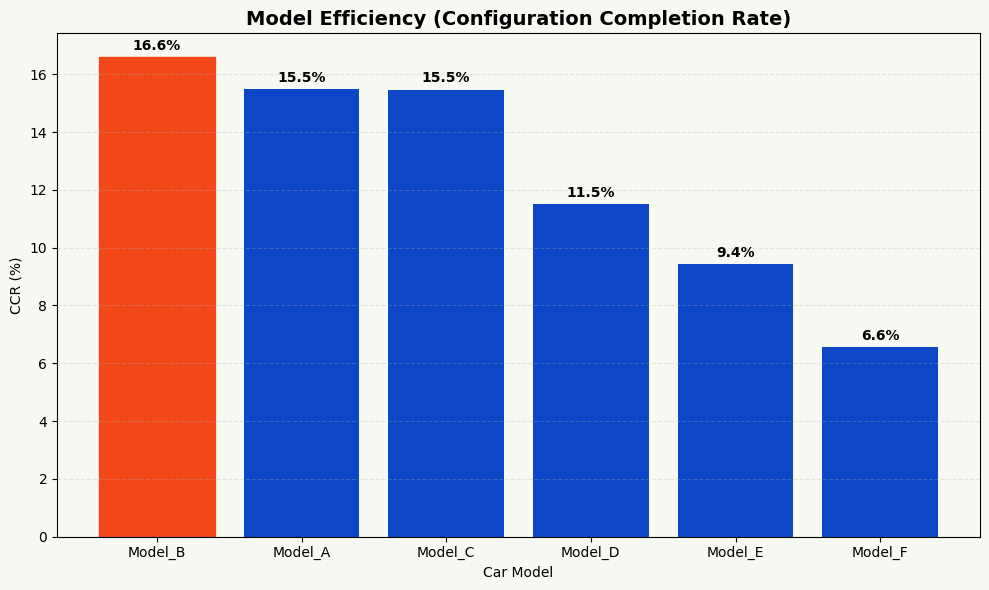

In [96]:
# Popularity Analysis: Efficiency (CCR)
# Ranking models by their Configuration Completion Rate to identify which models have the most engaging digital experience.

# Prepare Data
ccr_ranking = popularity_stats.sort_values(by='ccr_%', ascending=False)

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))
fig.set_facecolor('#f6faf3')
ax.set_facecolor('#f6faf3')

# Plotting CCR %
bars = ax.bar(ccr_ranking['model'], ccr_ranking['ccr_%'], color='#0d47c7')

# Highlight the top model in Orange
bars[0].set_color('#f24819')

ax.set_title('Model Efficiency (Configuration Completion Rate)', fontsize=14, fontweight='bold')
ax.set_ylabel('CCR (%)')
ax.set_xlabel('Car Model')

# Add data labels
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

Correlation to check which metric explains leads

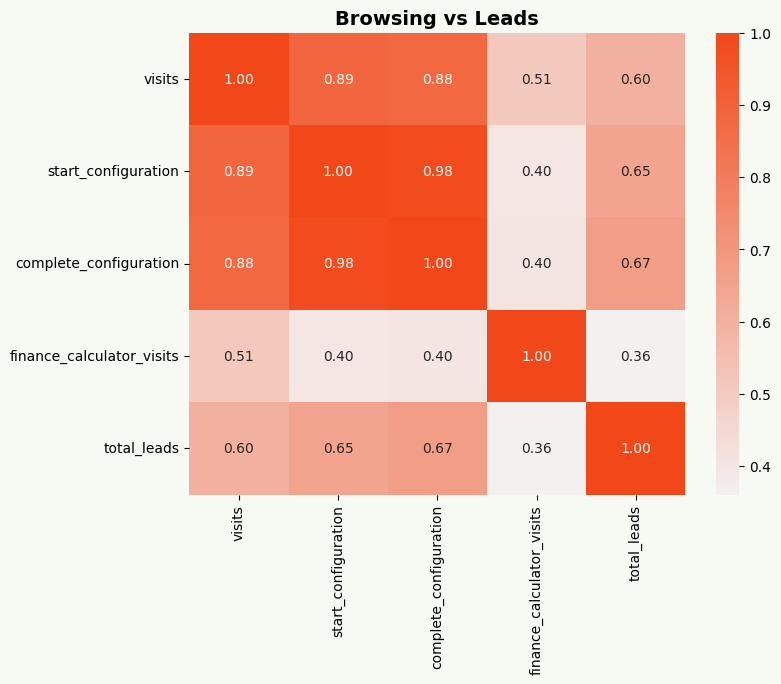

In [93]:
# Correlation Analysis
# Analyze the relationship between website browsing behavior and lead generation to identify which actions are the strongest 'predictors' of success.

# Selecting metrics for correlation
metrics_to_corr = ['visits', 'start_configuration', 'complete_configuration', 'finance_calculator_visits', 'total_leads']
corr_matrix = df_all[metrics_to_corr].corr()

# Plotting a Heatmap
fig, ax = plt.subplots(figsize=(8, 6))
fig.set_facecolor('#f6faf3')
sns.heatmap(corr_matrix, annot=True, cmap=sns.light_palette("#f24819", as_cmap=True), fmt=".2f", ax=ax)

ax.set_title('Browsing vs Leads', fontsize=14, fontweight='bold')
plt.show()

### Q2: With the goal of increasing leads, which model(s) have the most room for improvement, and why? What would be your next steps?

In [16]:
# Year-over-Year (YoY) Performance
# Comparing the growth of each model between 2023 and 2024
df_all['date'] = pd.to_datetime(df_all['date'])
df_all['year'] = df_all['date'].dt.year
yoy_analysis = df_all.groupby(['model', 'year']).agg({
    'visits': 'sum',
    'complete_configuration': 'sum'
}).unstack() # This moves the year to columns for easy subtraction

# Calculate % Growth in Visits
yoy_analysis['visit_growth_%'] = ((yoy_analysis['visits'][2024] - yoy_analysis['visits'][2023]) / yoy_analysis['visits'][2023]) * 100

print("YoY Growth by Model:")
print(yoy_analysis['visit_growth_%'].sort_values(ascending=False))

YoY Growth by Model:
model
Model_C    61.119420
Model_B    33.673890
Model_E    25.177205
Model_A    22.896476
Model_F   -20.662269
Model_D   -24.487204
Name: visit_growth_%, dtype: float64


In [17]:
# Traffic vs Leads
# Compare the volume growth (Visits) against lead growth (Configurations) 
# to calculate the 'Efficiency Gap'.

# % Growth for Leads (Configurations)
yoy_analysis['config_growth_%'] = (
    (yoy_analysis['complete_configuration'][2024] - yoy_analysis['complete_configuration'][2023]) 
    / yoy_analysis['complete_configuration'][2023]
) * 100

# Calculation of the difference in CCR
ccr_23 = (yoy_analysis['complete_configuration'][2023] / yoy_analysis['visits'][2023]) * 100
ccr_24 = (yoy_analysis['complete_configuration'][2024] / yoy_analysis['visits'][2024]) * 100
yoy_analysis['ccr_change_pp'] = ccr_24 - ccr_23

print("Strategic YoY Analysis:")
print(yoy_analysis[['visit_growth_%', 'config_growth_%', 'ccr_change_pp']])

Strategic YoY Analysis:
        visit_growth_% config_growth_% ccr_change_pp
year                                                
model                                               
Model_A      22.896476       18.447363     -0.572351
Model_B      33.673890      -13.383223     -7.313658
Model_C      61.119420       96.805635      3.015333
Model_D     -24.487204      -25.055083     -0.086774
Model_E      25.177205      -26.022160     -4.996001
Model_F     -20.662269      -17.129171      0.286946


In [23]:
# Configurator Funnel Deep Dive (Question 2) Is a marketing or UX issue? Focusing on Models B and E having C as the benchmark
# We break down the process into 'Start Rate' and 'Completion Rate'

# Calculating the rates for the master dataset (both years)
# How many visitors start a config?
df_all['start_rate_%'] = (df_all['start_configuration'] / df_all['visits']) * 100

# Of those who started, how many finished? (The Survival Rate)
df_all['completion_rate_%'] = (df_all['complete_configuration'] / df_all['start_configuration']) * 100

# Grouping by model and year to see the trend
funnel_analysis = df_all.groupby(['model', 'year']).agg({
    'start_rate_%': 'mean',
    'completion_rate_%': 'mean'
}).unstack()

# Focus on our specific models
target_models = ['Model_B', 'Model_C','Model_E']
print("Funnel Efficiency (Start vs. Completion):")
print(funnel_analysis.loc[target_models])

Funnel Efficiency (Start vs. Completion):
        start_rate_%            completion_rate_%           
year            2023       2024              2023       2024
model                                                       
Model_B    60.279345  37.822045         34.455807  35.436054
Model_C    49.160445  45.950862         28.796083  35.724833
Model_E    36.191520  22.329424         34.318236  31.468519


### Q3: How have leads changed year-on-year? What would you do with this information?

In [27]:
# The Engine (ICE vs BEV)
# Total leads based on the client's dictionary
# the YoY shift in demand

# Define the official Lead columns
lead_cols = ['test_drives_submitted', 'finance_calc_leads_submitted', 'request_a_quote_form_submitted']

# Create the column in the master dataset
df_all['total_leads'] = df_all[lead_cols].sum(axis=1)

# Group by engine type and year
engine_stats = df_all.groupby(['engine_type', 'year']).agg({
    'visits': 'sum',
    'total_leads': 'sum'
}).unstack()

# Calculate YoY growth for the segment
engine_stats['visit_growth_%'] = ((engine_stats['visits'][2024] - engine_stats['visits'][2023]) / engine_stats['visits'][2023]) * 100
engine_stats['lead_growth_%'] = ((engine_stats['total_leads'][2024] - engine_stats['total_leads'][2023]) / engine_stats['total_leads'][2023]) * 100

print("Macro Trend: ICE vs. BEV")
print(engine_stats[['visit_growth_%', 'lead_growth_%']])

Macro Trend: ICE vs. BEV
            visit_growth_% lead_growth_%
year                                    
engine_type                             
BEV              -3.840684     93.792240
ICE              19.812858     97.905326


In [41]:
from matplotlib.ticker import FuncFormatter

# Function to turn large numbers into 'Millions' format
def millions_formatter(x, pos):
    return f'{x*1e-6:.1f}M'

formatter = FuncFormatter(millions_formatter)

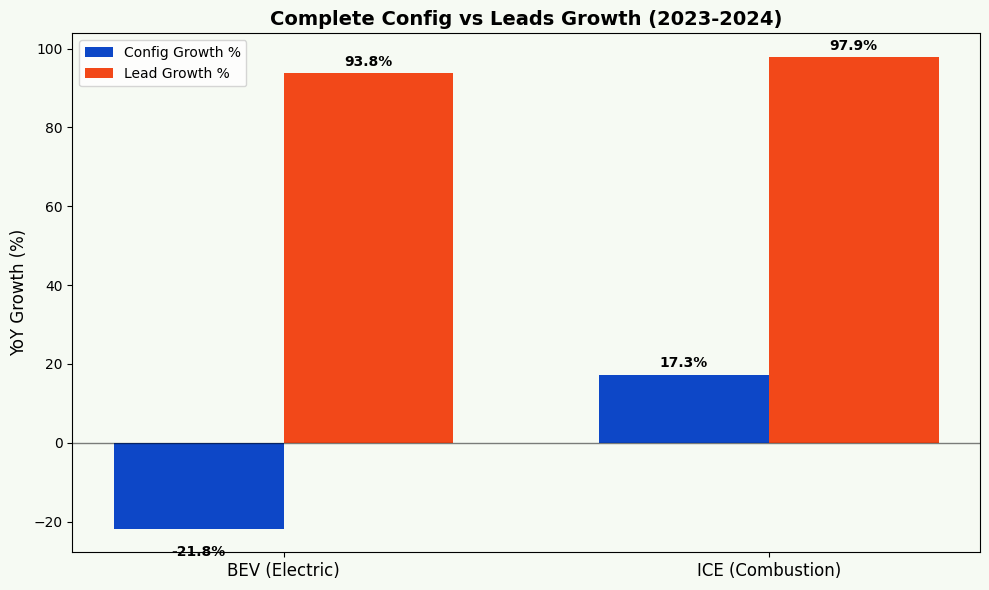

In [100]:
# Engine Performance (Config vs. Leads)
# We pivot to comparing 'Complete Configuration' growth against 'Lead' growth to analyze the efficiency of our highest-impact shopping action.

# Aggregate Data by Engine Type and Year
engine_analysis = df_all.groupby(['engine_type', 'year']).agg({
    'complete_configuration': 'sum',
    'total_leads': 'sum'
}).unstack()

# Calculate YoY Growth %
# Formula: ((2024 - 2023) / 2023) * 100
engine_analysis['config_growth_%'] = (
    (engine_analysis['complete_configuration'][2024] - engine_analysis['complete_configuration'][2023]) 
    / engine_analysis['complete_configuration'][2023]
) * 100

engine_analysis['lead_growth_%'] = (
    (engine_analysis['total_leads'][2024] - engine_analysis['total_leads'][2023]) 
    / engine_analysis['total_leads'][2023]
) * 100

# 3. Visualization Setup
labels = ['BEV (Electric)', 'ICE (Combustion)']
config_g = engine_analysis['config_growth_%'].values
lead_g = engine_analysis['lead_growth_%'].values

x = np.arange(len(labels))
width = 0.35

# Brand Hex Codes
bg_color = '#f6faf3'
config_color = '#0d47c7' # Brand Blue
lead_color = '#f24819'   # Brand Orange

fig, ax = plt.subplots(figsize=(10, 6))
fig.set_facecolor(bg_color)
ax.set_facecolor(bg_color)

# Plotting the bars
rects1 = ax.bar(x - width/2, config_g, width, label='Config Growth %', color=config_color)
rects2 = ax.bar(x + width/2, lead_g, width, label='Lead Growth %', color=lead_color)

# Standard formatting
ax.set_ylabel('YoY Growth (%)', fontsize=12)
ax.set_title('Complete Config vs Leads Growth (2023-2024)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.legend()

# Data Labels (The autolabel function you created)
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        offset = 3 if height >= 0 else -12
        va = 'bottom' if height >= 0 else 'top'
        ax.annotate(f'{height:.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, offset),
                    textcoords="offset points",
                    ha='center', va=va,
                    fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.axhline(0, color='black', linewidth=1, alpha=0.5)
plt.tight_layout()
plt.show()

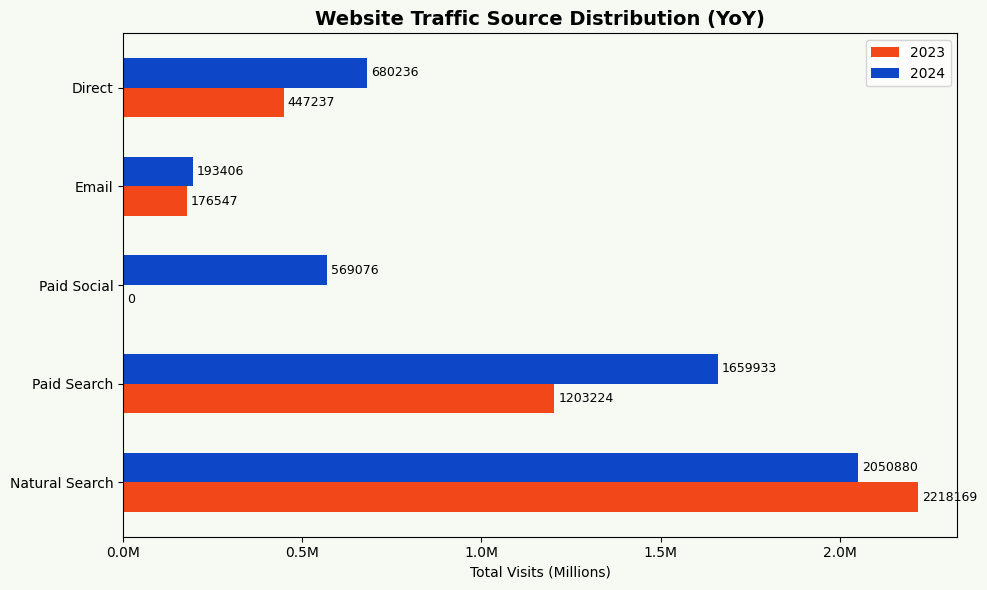

In [50]:
# Visualizing Channel Distribution
# How visits are distributed across different media channels YoY

# Define the channel columns
channel_cols = ['natural_search_visits', 'paid_search_visits', 'paid_social_visits', 'email_visits', 'direct_visits']
channel_data = df_all.groupby('year')[channel_cols].sum().T #Group by year

fig, ax = plt.subplots(figsize=(10, 6))
fig.set_facecolor('#f6faf3')
ax.set_facecolor('#f6faf3')

# Plotting
bars = channel_data.plot(kind='barh', ax=ax, color=['#f24819', '#0d47c7'], width=0.6)

# Apply the Millions formatter
ax.xaxis.set_major_formatter(formatter)

# This puts the actual number next to the bar for precision
for container in ax.containers:
    ax.bar_label(container, padding=3, fmt='%.0f', fontsize=9)

ax.set_title('Website Traffic Source Distribution (YoY)', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Visits (Millions)')
ax.set_yticklabels(['Natural Search', 'Paid Search', 'Paid Social', 'Email', 'Direct'])
ax.legend(['2023', '2024'])

plt.tight_layout()
plt.show()

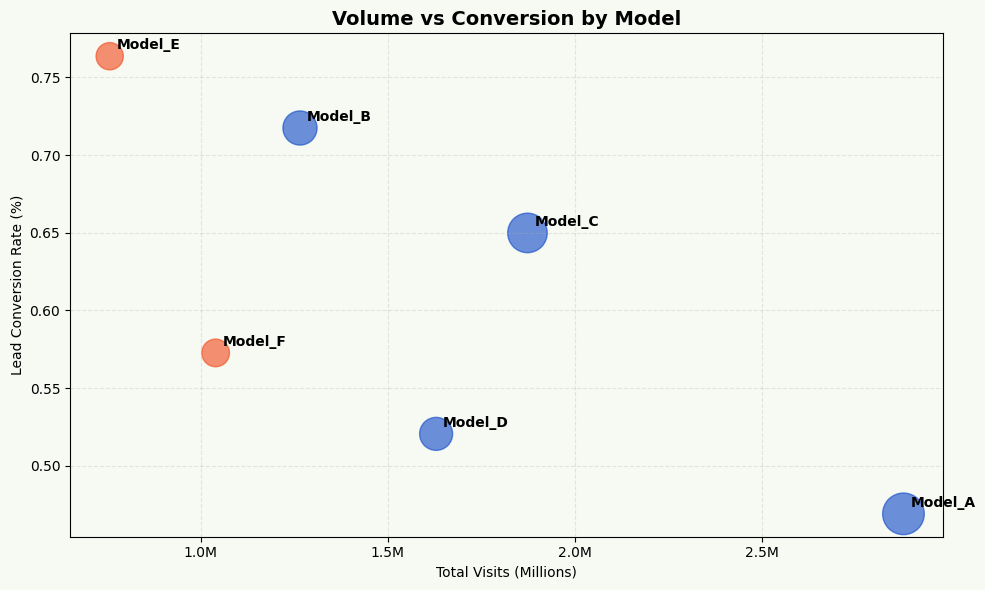

In [ ]:
# Identifying 'Volume Leaders' vs 'Efficiency Leaders'
# Calculate Lead Conversion Rate (LCR) per model

model_perf = df_all.groupby('model').agg({'visits': 'sum', 'total_leads': 'sum'}).reset_index()
model_perf['lcr_%'] = (model_perf['total_leads'] / model_perf['visits']) * 100

# Highlight electriv engines
highlight_models = ['Model_E', 'Model_F']
colors = ['#f24819' if m in highlight_models else '#0d47c7' for m in model_perf['model']]

fig, ax = plt.subplots(figsize=(10, 6))
fig.set_facecolor('#f6faf3')
ax.set_facecolor('#f6faf3')

# Size of bubble is determined by total leads
ax.scatter(model_perf['visits'], model_perf['lcr_%'], s=model_perf['total_leads']/15, alpha=0.6, color=colors)

# Apply the Millions formatter to X-axis
ax.xaxis.set_major_formatter(formatter)

for i, txt in enumerate(model_perf['model']):
    ax.annotate(txt, (model_perf['visits'][i], model_perf['lcr_%'][i]), xytext=(5,5), textcoords='offset points', fontweight='bold')

ax.set_title('Volume vs Conversion by Model', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Visits (Millions)')
ax.set_ylabel('Lead Conversion Rate (%)')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

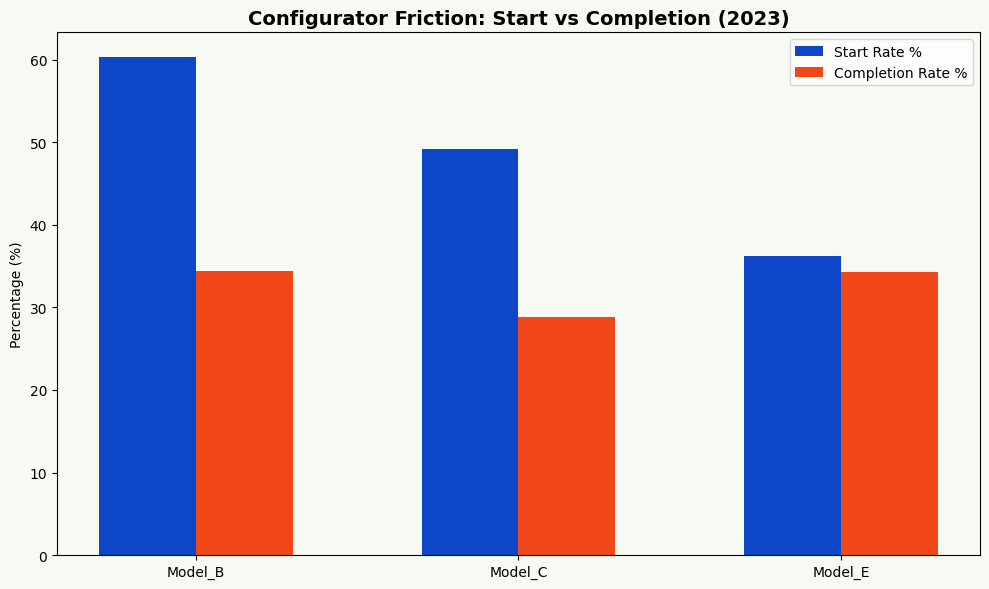

In [69]:
# Comparing Start Rate vs Completion Rate for key models in 2023

# Get data for 2023 specifically
df_24_only = df_all[df_all['year'] == 2023]

# Group by model
funnel_24 = df_24_only.groupby('model').agg({
    'start_rate_%': 'mean',
    'completion_rate_%': 'mean'
})

# Focus on specific targets
target_models = ['Model_B', 'Model_C', 'Model_E']
plot_data = funnel_24.loc[target_models]

x_axis = np.arange(len(target_models))
width = 0.3

fig, ax = plt.subplots(figsize=(10, 6))
fig.set_facecolor('#f6faf3')
ax.set_facecolor('#f6faf3')

ax.bar(x_axis - width/2, plot_data['start_rate_%'], width, label='Start Rate %', color='#0d47c7')
ax.bar(x_axis + width/2, plot_data['completion_rate_%'], width, label='Completion Rate %', color='#f24819')

ax.set_title('Configurator Friction: Start vs Completion (2023)', fontsize=14, fontweight='bold')
ax.set_xticks(x_axis)
ax.set_xticklabels(target_models)
ax.set_ylabel('Percentage (%)')
ax.legend()

plt.tight_layout()
plt.show()

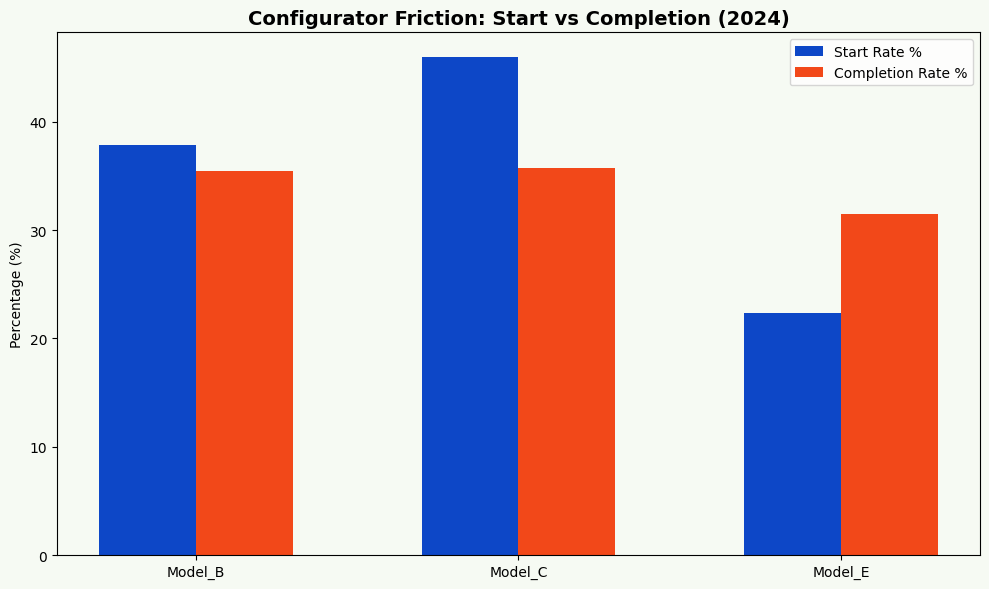

In [68]:
# Comparing Start Rate vs Completion Rate for key models in 2024

# Get data for 2024 specifically
df_24_only = df_all[df_all['year'] == 2024]

# Group by model
funnel_24 = df_24_only.groupby('model').agg({
    'start_rate_%': 'mean',
    'completion_rate_%': 'mean'
})

# Focus on specific targets
target_models = ['Model_B', 'Model_C', 'Model_E']
plot_data = funnel_24.loc[target_models]

x_axis = np.arange(len(target_models))
width = 0.3

fig, ax = plt.subplots(figsize=(10, 6))
fig.set_facecolor('#f6faf3')
ax.set_facecolor('#f6faf3')

ax.bar(x_axis - width/2, plot_data['start_rate_%'], width, label='Start Rate %', color='#0d47c7')
ax.bar(x_axis + width/2, plot_data['completion_rate_%'], width, label='Completion Rate %', color='#f24819')

ax.set_title('Configurator Friction: Start vs Completion (2024)', fontsize=14, fontweight='bold')
ax.set_xticks(x_axis)
ax.set_xticklabels(target_models)
ax.set_ylabel('Percentage (%)')
ax.legend()

plt.tight_layout()
plt.show()

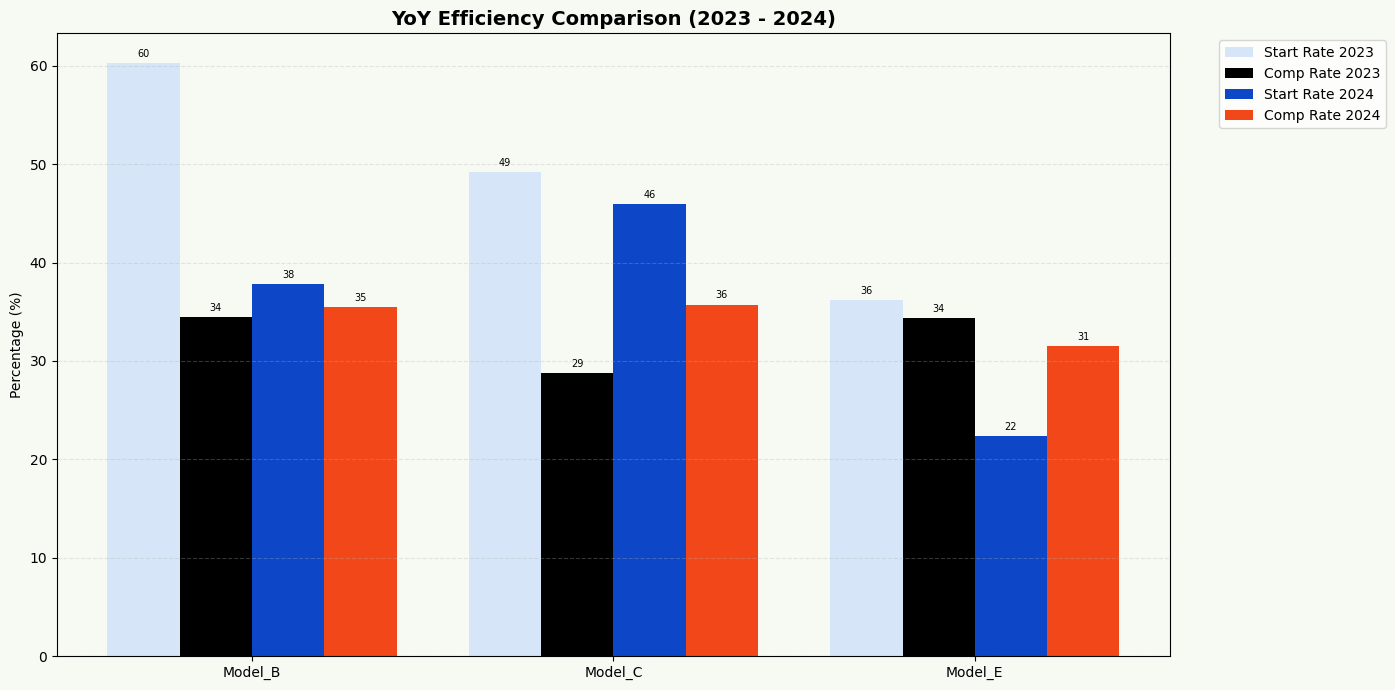

In [73]:
# Funnel Comparison (2023 vs 2024)
# Visualizing the efficiency table to show the 'Friction' trend over time.

funnel_data = df_all.groupby(['model', 'year'])[['start_rate_%', 'completion_rate_%']].mean().unstack()
plot_data = funnel_data.loc[['Model_B', 'Model_C', 'Model_E']]

fig, ax = plt.subplots(figsize=(14, 7))
fig.set_facecolor('#f6faf3')
ax.set_facecolor('#f6faf3')

x_axis = np.arange(len(plot_data))
w = 0.2 # width of bars

# 2023 
ax.bar(x_axis - 1.5*w, plot_data['start_rate_%'][2023], w, label='Start Rate 2023', color='#d6e6f8')
ax.bar(x_axis - 0.5*w, plot_data['completion_rate_%'][2023], w, label='Comp Rate 2023', color='#000000')

# 2024 
ax.bar(x_axis + 0.5*w, plot_data['start_rate_%'][2024], w, label='Start Rate 2024', color='#0d47c7')
ax.bar(x_axis + 1.5*w, plot_data['completion_rate_%'][2024], w, label='Comp Rate 2024', color='#f24819')

for container in ax.containers:
    ax.bar_label(container, padding=3, fmt='%.0f', fontsize=7)

ax.set_title('YoY Efficiency Comparison (2023 - 2024)', fontsize=14, fontweight='bold')
ax.set_xticks(x_axis)
ax.set_xticklabels(['Model_B', 'Model_C', 'Model_E'])
ax.set_ylabel('Percentage (%)')
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1))
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Seasonality Exploration

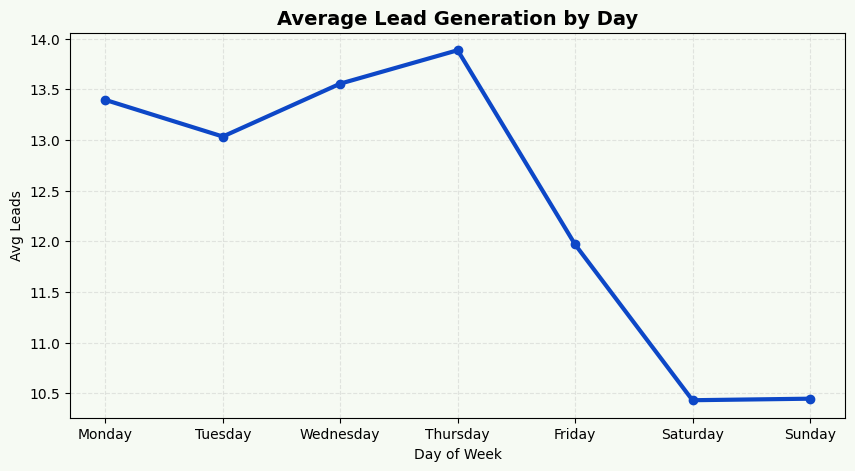

In [ ]:
# Seasonality (Months & Days)
# Identifying 'Peak Performance' moments to optimize marketing spend

# Ensure date is datetime
df_all['date'] = pd.to_datetime(df_all['date'])
df_all['day_name'] = df_all['date'].dt.day_name()
df_all['month'] = df_all['date'].dt.month

# Order days for the plot
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Calculate avg Leads per day of week
dow_leads = df_all.groupby('day_name')['total_leads'].mean().reindex(days_order)

# Plotting day of week performance
fig, ax = plt.subplots(figsize=(10, 5))
fig.set_facecolor('#f6faf3')
ax.set_facecolor('#f6faf3')

dow_leads.plot(kind='line', marker='o', color='#0d47c7', linewidth=3, ax=ax)
ax.set_title('Average Lead Generation by Day', fontsize=14, fontweight='bold')
ax.set_ylabel('Avg Leads')
ax.set_xlabel('Day of Week')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

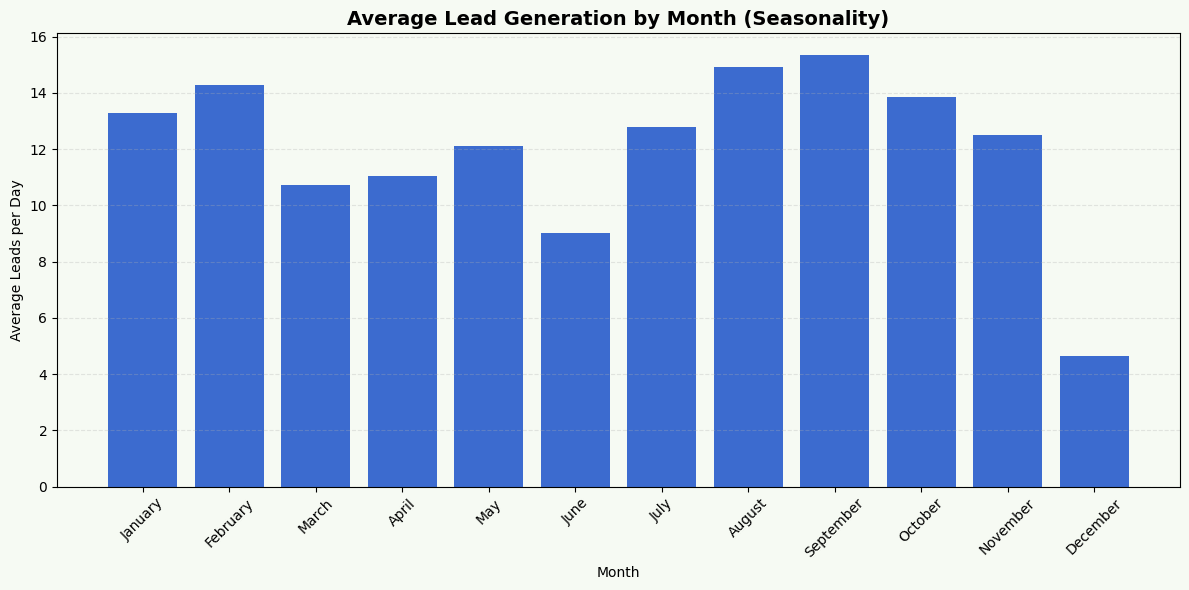

In [ ]:
# Time-Series Analysis: Monthly 
# Average daily leads per month to identify high-intent seasons and optimize marketing scheduling

# Prepare Monthly Data
df_all['month_num'] = df_all['date'].dt.month
df_all['month_name'] = df_all['date'].dt.month_name()

# Calculate mean leads per month
# We group by both to keep the numeric order for sorting
monthly_avg = df_all.groupby(['month_num', 'month_name'])['total_leads'].mean().reset_index()

# Plotting
fig, ax = plt.subplots(figsize=(12, 6))
fig.set_facecolor('#f6faf3')
ax.set_facecolor('#f6faf3')

ax.bar(monthly_avg['month_name'], monthly_avg['total_leads'], color='#0d47c7', alpha=0.8)

ax.set_title('Average Lead Generation by Month', fontsize=14, fontweight='bold')
ax.set_ylabel('Average Leads per Day')
ax.set_xlabel('Month')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

c:\Users\sebas\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


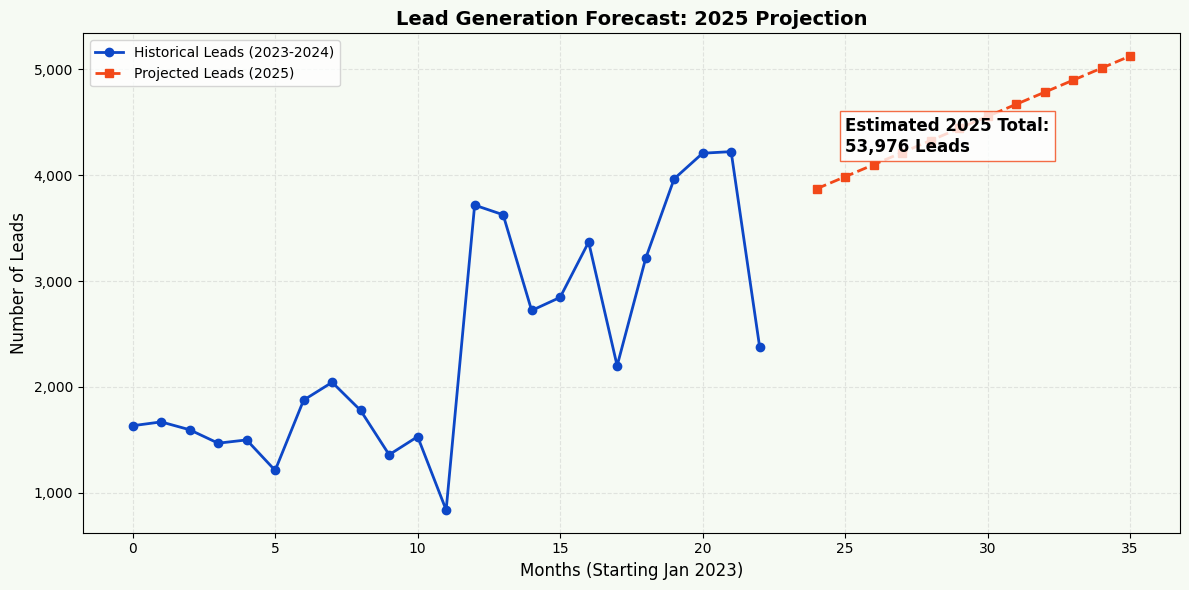

In [ ]:
# Predictive Analytics: 2025 Lead Forecast
# Using a Linear Regression model to project future lead volume based on current growth trends

from sklearn.linear_model import LinearRegression
import matplotlib.ticker as ticker

# Data (Aggregated by month)
ts_data = df_all.groupby(['year', 'month'])['total_leads'].sum().reset_index()
ts_data['time_index'] = np.arange(len(ts_data))

# Train Model
X = ts_data[['time_index']]
y = ts_data['total_leads']
model = LinearRegression().fit(X, y)

# Predict 2025
future_indices = np.array(range(24, 36)).reshape(-1, 1)
preds_2025 = model.predict(future_indices)
total_2025_est = preds_2025.sum()

# Plotting
plt.figure(figsize=(12, 6), facecolor='#f6faf3')
ax = plt.gca()
ax.set_facecolor('#f6faf3')

# Historical Data
plt.plot(ts_data['time_index'], y, label='Historical Leads (2023-2024)', 
         color='#0d47c7', marker='o', linewidth=2)

# Forecast Data
plt.plot(future_indices, preds_2025, label='Projected Leads (2025)', 
         color='#f24819', linestyle='--', marker='s', linewidth=2)

# Formatting Axes
ax.set_title('Lead Generation Forecast: 2025 Projection', fontsize=14, fontweight='bold')
ax.set_xlabel('Months (Starting Jan 2023)', fontsize=12)
ax.set_ylabel('Number of Leads', fontsize=12)

# Use a comma separator for thousands on the Y-axis
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# Adding a summary box with the final number
stats_text = f'Estimated 2025 Total:\n{total_2025_est:,.0f} Leads'
plt.text(25, y.max(), stats_text, fontsize=12, fontweight='bold',
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='#f24819'))

plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

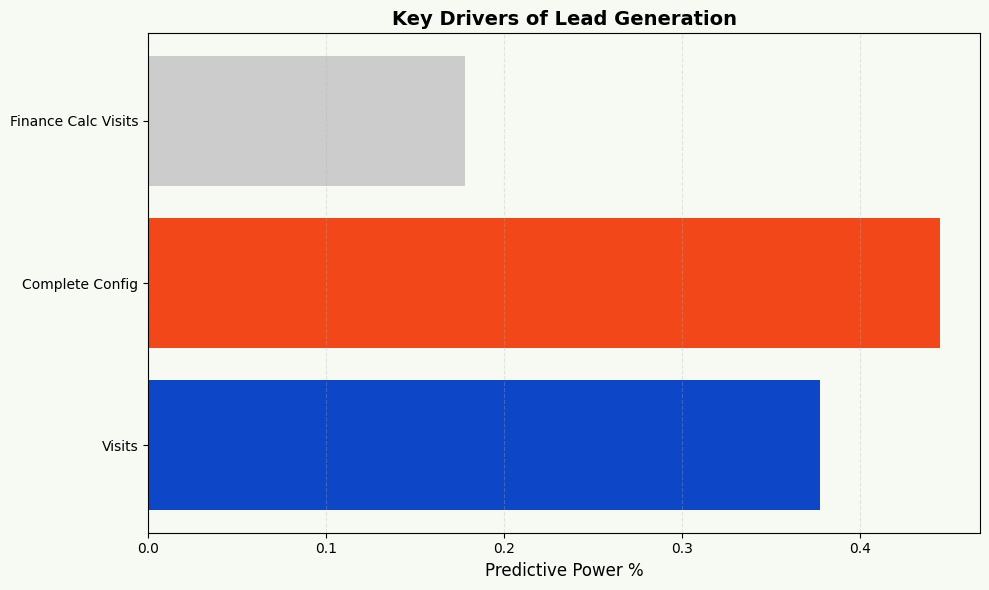

In [ ]:
# Key Drivers of Lead Generation
# Random Forest model to determine which user actions are the primary 'Predictors' of success

from sklearn.ensemble import RandomForestRegressor

# Defining Features (X) and Target (y)
features = ['visits', 'complete_configuration', 'finance_calculator_visits']
X = df_all[features]
y = df_all['total_leads']

# Training the Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X, y)

# Extracting Importance
importances = rf_model.feature_importances_

# Refined Labels for the Audience
clean_labels = ['Visits', 'Complete Config', 'Finance Calc Visits']

# Plotting with Brand Colors
plt.figure(figsize=(10, 6), facecolor='#f6faf3')
ax = plt.gca()
ax.set_facecolor('#f6faf3')

# Brand blue for the top driver and brand orange/grey for others
plt.barh(clean_labels, importances, color=['#0d47c7', '#f24819', '#CCCCCC'])

ax.set_title('Key Drivers of Lead Generation', fontsize=14, fontweight='bold')
ax.set_xlabel('Predictive Power %', fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

469
